In [1]:
import torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
import kagglehub 
import time
import copy

from collections import Counter # 


# 다운로드 및 경로 설정

path = '/home/workstation/.cache/kagglehub/datasets/nizier193/strawberry-disease-classification/versions/1'

print("다운로드된 데이터셋 경로:", path)

# GPU 사용 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

다운로드된 데이터셋 경로: /home/workstation/.cache/kagglehub/datasets/nizier193/strawberry-disease-classification/versions/1
사용 장치: cuda:0


/home/workstation/anaconda3/envs/env_realtemp/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/workstation/anaconda3/envs/env_realtemp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==============================================================================
# 2. 데이터셋 경로 설정 
# ==============================================================================
import os


DATA_ROOT_DOWNLOAD = path
print(f"DEBUG: 다운로드 루트 경로: {DATA_ROOT_DOWNLOAD}")


TARGET_FOLDER = 'union_dataset'


DATA_ROOT_FOR_SPLIT = os.path.join(DATA_ROOT_DOWNLOAD, TARGET_FOLDER)

print(f"\n✅ 최종 데이터 로드 경로 (DATA_ROOT_FOR_SPLIT): {DATA_ROOT_FOR_SPLIT}")


if not os.path.exists(DATA_ROOT_FOR_SPLIT):
    print(f"❌ 오류: 경로를 찾을 수 없습니다. : {DATA_ROOT_FOR_SPLIT}")
else:
    print(f"✅ 경로 확인 완료: {DATA_ROOT_FOR_SPLIT}")
    print("     '4. 데이터 로드' 섹션을 실행하세요.")

DEBUG: 다운로드 루트 경로: /home/workstation/.cache/kagglehub/datasets/nizier193/strawberry-disease-classification/versions/1

✅ 최종 데이터 로드 경로 (DATA_ROOT_FOR_SPLIT): /home/workstation/.cache/kagglehub/datasets/nizier193/strawberry-disease-classification/versions/1/union_dataset
✅ 경로 확인 완료: /home/workstation/.cache/kagglehub/datasets/nizier193/strawberry-disease-classification/versions/1/union_dataset
     '4. 데이터 로드' 섹션을 실행하세요.


In [4]:
import sys
print(sys.executable)

/home/workstation/anaconda3/envs/env_realtemp/bin/python


In [ ]:
# ==============================================================================
# 3. 하이퍼파라미터 및 데이터 변환 설정 
# ==============================================================================
from efficientnet_pytorch import EfficientNet

# 하이퍼파라미터
BATCH_SIZE = 32 
NUM_EPOCHS = 10
LEARNING_RATE = 0.0001 
MODEL_NAME = 'efficientnet-b0' 


INPUT_SIZE = EfficientNet.get_image_size(MODEL_NAME)

# 데이터 증강 및 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.RandomResizedCrop(INPUT_SIZE),
        
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ]),
    'test': transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.CenterCrop(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
# ==============================================================================
# 4. 데이터 로드 및 DataLoader 생성 
# ==============================================================================
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

print("\n데이터 로딩 및 안전한 90:10 분할 중...")


full_dataset = ImageFolder(DATA_ROOT_FOR_SPLIT, data_transforms['train']) 
full_size = len(full_dataset)

# 2. 비율 설정 (90% 학습, 10% 검증)
train_size = int(0.9 * full_size)
val_size = full_size - train_size


train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)


dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
    
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
}

# 5. 메타 정보 업데이트
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print(f"클래스 개수: {NUM_CLASSES}")
print(f"클래스 이름: {class_names}")
print(f"✅ 새로운 학습 데이터 크기: {dataset_sizes['train']} (90%)")
print(f"✅ 새로운 검증 데이터 크기: {dataset_sizes['val']} (10%)")


데이터 로딩 및 안전한 90:10 분할 중...
클래스 개수: 77
클래스 이름: ['Strawberry___Leaf_scorch', 'Strawberry___healthy', 'alternaria_leaf_blight', 'angular_leafspot', 'anthocyanosis', 'anthracnose', 'anthracnose_fruit_rot', 'ants', 'aphid', 'aphid_effects', 'ascochyta_blight', 'bacterial_spot', 'black_chaff', 'black_rot', 'black_spots', 'blossom_blight', 'blossom_end_rot', 'botrytis_cinerea', 'burn', 'calciumdeficiency', 'canker', 'caterpillars', 'cherry_leaf_spot', 'coccomyces_of_pome_fruits', 'colorado_beetle', 'colorado_beetle_effects', 'corn_downy_mildew', 'cyclamen_mite', 'downy_mildew', 'dry_rot', 'edema', 'esca', 'eyespot', 'frost_cracks', 'galls', 'gray_mold', 'grey_mold', 'gryllotalpa', 'gryllotalpa_effects', 'healthy', 'late_blight', 'leaf_deformation', 'leaf_miners', 'leaf_spot', 'leaves_scorch', 'lichen', 'loss_of_foliage_turgor', 'marginal_leaf_necrosis', 'mealybug', 'mechanical_damage', 'monilia', 'mosaic_virus', 'northern_leaf_blight', 'nutrient_deficiency', 'pear_blister_mite', 'pest_damage

In [25]:
class_names = full_dataset.classes

In [ ]:
# ==============================================================================
# 5. 모델 설정 및 가중치 부여 손실 함수 설정 
# ==============================================================================
from collections import Counter
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

# ==============================================================================
# 1. 클래스 가중치 계산 
# ==============================================================================
from collections import Counter


train_targets = full_dataset.targets 
class_counts = Counter(train_targets)
total_count = sum(class_counts.values())

class_weights = [total_count / class_counts[i] for i in range(NUM_CLASSES)]
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights / class_weights.min()

print(f"✅ 클래스 가중치 계산 완료: {class_weights.tolist()}")


# ----------------------------------------------------------------------
# 2. EfficientNet-B0 모델 로드 및 분류 레이어 명시적 교체 
# ----------------------------------------------------------------------


model_ft = EfficientNet.from_pretrained(MODEL_NAME).to(device)


num_ftrs = model_ft._fc.in_features


model_ft._fc = nn.Sequential(
    nn.Dropout(0.5), 
    nn.Linear(num_ftrs, NUM_CLASSES)
)

model_ft = model_ft.to(device) 

print(f"✅ EfficientNet-B0의 최종 분류 레이어(w/ Dropout)가 {num_ftrs} -> {NUM_CLASSES}로 성공적으로 교체되었습니다.")


# ----------------------------------------------------------------------
# 3. Loss, Optimizer, Scheduler 정의
# ----------------------------------------------------------------------


criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


optimizer_ft = optim.AdamW(model_ft.parameters(), lr=LEARNING_RATE)


exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=8, gamma=0.5)

print("✅ Loss, Optimizer, Scheduler 정의 완료.")


✅ 클래스 가중치 계산 완료: [1.0, 2.4320175647735596, 28.435895919799805, 2.8290815353393555, 36.96666717529297, 32.61764907836914, 13.04705810546875, 29.972970962524414, 24.108694076538086, 16.803030014038086, 25.204544067382812, 20.16363525390625, 29.972970962524414, 29.972970962524414, 27.04878044128418, 6.195530414581299, 24.644445419311523, 58.3684196472168, 8.801587104797363, 1.3776397705078125, 30.805553436279297, 25.79069709777832, 19.120689392089844, 30.805553436279297, 31.685714721679688, 39.60714340209961, 30.805553436279297, 38.24137878417969, 25.204544067382812, 15.619717597961426, 18.79660987854004, 15.191780090332031, 29.972970962524414, 23.595745086669922, 16.55223846435547, 2.7725000381469727, 14.402596473693848, 44.36000061035156, 42.653846740722656, 1.357405185699463, 15.402776718139648, 16.803030014038086, 14.5921049118042, 1.8607381582260132, 25.79069709777832, 17.603174209594727, 14.03797435760498, 7.809858798980713, 14.786665916442871, 19.456140518188477, 34.65625, 14.59210

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /home/workstation/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:01<00:00, 14.8MB/s]


Loaded pretrained weights for efficientnet-b0
✅ EfficientNet-B0의 최종 분류 레이어(w/ Dropout)가 1280 -> 77로 성공적으로 교체되었습니다.
✅ Loss, Optimizer, Scheduler 정의 완료.


In [ ]:
# ==============================================================================
# 6. 모델 학습 함수 
# ==============================================================================
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f'\nEpoch {epoch+1}/{num_epochs}'); print('-' * 10)

        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'-> New best model found! Saving weights with Acc: {best_acc:.4f}')

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch Time: {epoch_time:.0f}초')

    time_elapsed = time.time() - since
    print(f'\n학습 완료! 총 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초')
    print(f'최고 검증 정확도: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# ==============================================================================
# 7. 모델 학습 실행 및 저장
# ==============================================================================

# 모델 학습 시작
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

# Google Drive 마운트
drive.mount('/content/drive')
MODEL_SAVE_PATH = '/content/drive/MyDrive/disease_model.pth' 

MODEL_SAVE_PATH = 'model/disease_model.pth'
# 모델 저장
torch.save(model_ft.state_dict(), MODEL_SAVE_PATH)
print(f"\n✅ 최적 모델 가중치가 {MODEL_SAVE_PATH}에 저장되었습니다.")


Epoch 1/10
----------
train Loss: 4.1603 Acc: 0.2125
val Loss: 3.8273 Acc: 0.4418
-> New best model found! Saving weights with Acc: 0.4418
Epoch Time: 209초

Epoch 2/10
----------
train Loss: 3.5895 Acc: 0.4806
val Loss: 3.1354 Acc: 0.5713
-> New best model found! Saving weights with Acc: 0.5713
Epoch Time: 203초

Epoch 3/10
----------
train Loss: 2.8109 Acc: 0.5797
val Loss: 2.2509 Acc: 0.6638
-> New best model found! Saving weights with Acc: 0.6638
Epoch Time: 203초

Epoch 4/10
----------
train Loss: 2.1656 Acc: 0.6430
val Loss: 1.7179 Acc: 0.7138
-> New best model found! Saving weights with Acc: 0.7138
Epoch Time: 197초

Epoch 5/10
----------
train Loss: 1.8033 Acc: 0.6754
val Loss: 1.5713 Acc: 0.7116
Epoch Time: 213초

Epoch 6/10
----------
train Loss: 1.5835 Acc: 0.7073
val Loss: 1.4951 Acc: 0.7312
-> New best model found! Saving weights with Acc: 0.7312
Epoch Time: 271초

Epoch 7/10
----------
train Loss: 1.4228 Acc: 0.7278
val Loss: 1.4270 Acc: 0.7476
-> New best model found! Saving 

NameError: name 'MODEL_SAVE_PATH' is not defined

In [11]:
MODEL_SAVE_PATH = 'model/disease_model.pth'
# 모델 저장
torch.save(model_ft.state_dict(), MODEL_SAVE_PATH)
print(f"\n✅ 최적 모델 가중치가 {MODEL_SAVE_PATH}에 저장되었습니다.")


✅ 최적 모델 가중치가 model/disease_model.pth에 저장되었습니다.


In [ ]:
# ==============================================================================
# 8. ONNX 모델 변환 및 저장 (별도 블럭)
# ==============================================================================

!pip install onnxscript
!pip install onnx
!pip install onnxruntime



ONNX_SAVE_PATH = 'strawberry_disease_model.onnx'


model_ft.eval()


dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=device)

# 3. ONNX로 내보내기
try:
    torch.onnx.export(
        model_ft,                   
        dummy_input,                
        ONNX_SAVE_PATH,             
        export_params=True,         
        opset_version=11,           
        do_constant_folding=True,   
        input_names = ['input'],    
        output_names = ['output'],  
        dynamic_axes={'input' : {0 : 'batch_size'},    
                      'output' : {0 : 'batch_size'}}
    )
    print(f"\n✅ 모델이 ONNX 형식으로 {ONNX_SAVE_PATH}에 성공적으로 저장되었습니다.")

except Exception as e:
    print(f"\n❌ ONNX 변환 중 오류 발생: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 14.0 MB/s eta 0:00:00


/tmp/ipython-input-766267436.py:25: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1126 09:07:51.784000 1092 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false`

Applied 115 of general pattern rewrite rules.

✅ 모델이 ONNX 형식으로 strawberry_disease_model.onnx에 성공적으로 저장되었습니다.


In [ ]:
import pandas as pd
import os


final_dataset = val_dataset
print(f"최종 평가 데이터 개수: {len(final_dataset)}개")


def create_dataset_metadata(dataset, class_names):
    data_list = []
    if hasattr(dataset, 'indices'):
        for idx in dataset.indices:
            path, label_idx = dataset.dataset.samples[idx]
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })
    else:
        for path, label_idx in dataset.samples:
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })
    return pd.DataFrame(data_list)

# 3. CSV 저장
df_final = create_dataset_metadata(final_dataset, class_names)
df_final.to_csv('final_strawberry_dataset_metadata.csv', index=False, encoding='utf-8-sig') # 파일명 변경
print("✅ 메타데이터 저장 완료")

최종 평가 데이터 개수: 919개
✅ 메타데이터 저장 완료


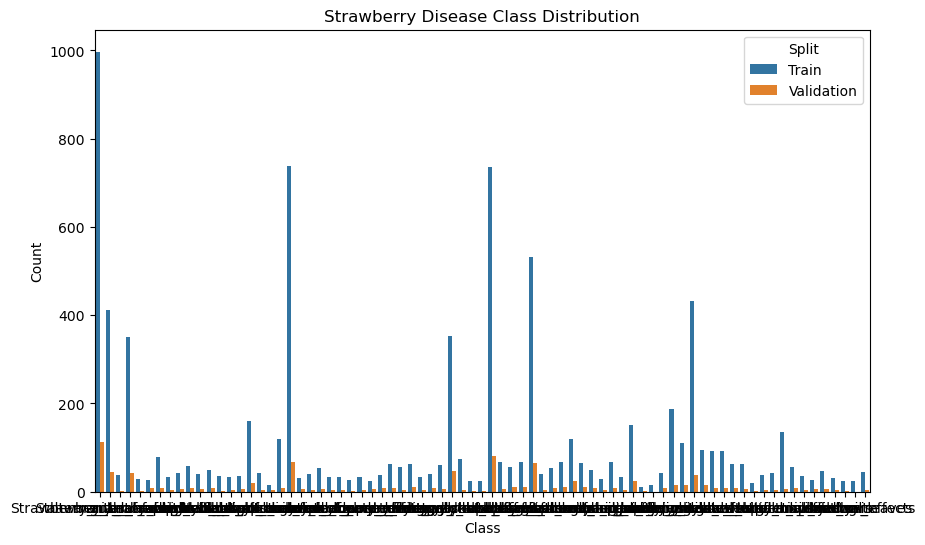

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def get_label_counts(dataset):
    if hasattr(dataset, 'indices'):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets
    return Counter(labels)

train_counts = get_label_counts(train_dataset)
val_counts = get_label_counts(val_dataset)

plot_data = []
for idx, name in enumerate(class_names):
    plot_data.append({'Class': name, 'Count': train_counts[idx], 'Split': 'Train'})
    plot_data.append({'Class': name, 'Count': val_counts[idx], 'Split': 'Validation'})
df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6)) 
sns.barplot(data=df_plot, x='Class', y='Count', hue='Split')
plt.title('Strawberry Disease Class Distribution')
plt.show()

/home/workstation/anaconda3/envs/env_realtemp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/workstation/anaconda3/envs/env_realtemp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/workstation/anaconda3/envs/env_realtemp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

                            precision    recall  f1-score   support

  Strawberry___Leaf_scorch       0.98      0.99      0.99       112
      Strawberry___healthy       1.00      0.98      0.99        45
    alternaria_leaf_blight       1.00      0.50      0.67         2
          angular_leafspot       0.93      0.90      0.91        41
             anthocyanosis       0.00      0.00      0.00         1
               anthracnose       0.75      0.43      0.55         7
     anthracnose_fruit_rot       0.71      0.71      0.71         7
                      ants       0.50      0.25      0.33         4
                     aphid       0.14      0.20      0.17         5
             aphid_effects       0.62      0.62      0.62         8
          ascochyta_blight       0.20      0.20      0.20         5
            bacterial_spot       0.00      0.00      0.00         7
               black_chaff       0.67      1.00      0.80         2
                 black_rot       0.50      0.75

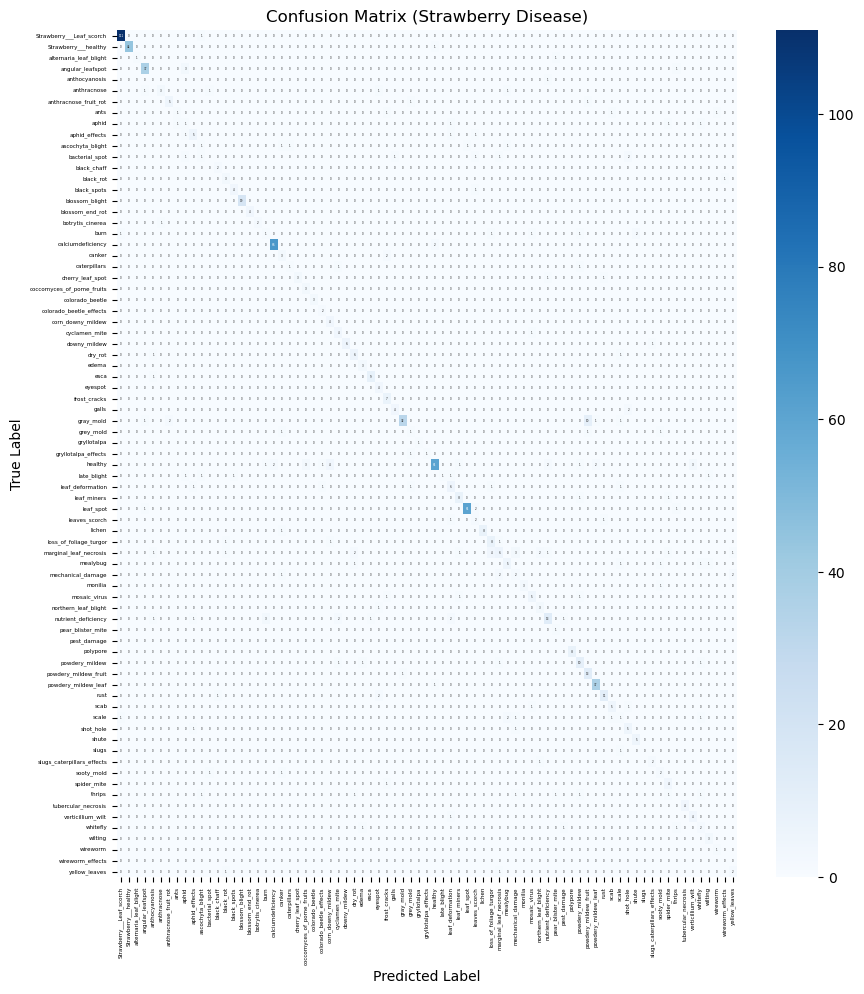

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

model_ft.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 11)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 2}, 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Strawberry Disease)')
plt.xticks(fontsize=4, rotation=90)   
plt.yticks(fontsize=4, rotation=0)    
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('strawberry.pdf', dpi=1200)
plt.show()